## Stage 1 — Feature Engineering & Exploratory Data Analysis (MovieLens small)

**Objective:**  
Clean, explore, and perform basic feature engineering on the MovieLens dataset, then generate insights for recommendation systems.

**Deliverables:**  
- Cleaned dataset (`cleaned_movies.csv`)  
- 6 new features  
- 6 visualizations with insights  
- 6-page report (`short_report.pdf`)

**Dataset files inside `ml-latest-small.zip`:**  
- `ratings.csv` → userId, movieId, rating, timestamp  
- `movies.csv` → movieId, title, genres  
- `tags.csv` → userId, movieId, tag, timestamp  
- `links.csv` → movieId, imdbId, tmdbId


In [52]:
# Step 1: Import libraries and set file paths

import os
import zipfile
import pandas as pd
import numpy as np
import re
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Paths
ZIP_PATH = "ml-latest-small.zip"  # your MovieLens zip file
WORKDIR = "ml_analysis_output"
EXTRACT_DIR = os.path.join(WORKDIR, "ml-latest-small")

# Make sure the folder exists
os.makedirs(WORKDIR, exist_ok=True)

print("Setup complete")


Setup complete


In [53]:
# Step 2: Unzip the dataset (only if not already extracted)

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(WORKDIR)
        print("Files extracted:")
        for name in z.namelist():
            print(" -", name)
else:
    print("Already extracted")

# Let's see what was extracted
for f in sorted(os.listdir(EXTRACT_DIR)):
    print("-", f)


Already extracted
- README.txt
- links.csv
- movies.csv
- ratings.csv
- tags.csv


In [54]:
# Step 3: Load the datasets

# Load the CSVs
ratings = pd.read_csv(os.path.join(EXTRACT_DIR, "ratings.csv"))
movies  = pd.read_csv(os.path.join(EXTRACT_DIR, "movies.csv"))
tags    = pd.read_csv(os.path.join(EXTRACT_DIR, "tags.csv"))
links   = pd.read_csv(os.path.join(EXTRACT_DIR, "links.csv"))

# Quick check of shapes
print("ratings:", ratings.shape)
print("movies:", movies.shape)
print("tags:", tags.shape)
print("links:", links.shape)

# Peek at first few rows
ratings.head()


ratings: (100836, 4)
movies: (9742, 3)
tags: (3683, 4)
links: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [55]:
# Step 4: Data preparation and merging

# Convert timestamps to datetime format
ratings['rating_timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
tags['tag_timestamp'] = pd.to_datetime(tags['timestamp'], unit='s')

# Merge ratings with movies and links
df = ratings.merge(movies, on='movieId', how='left')
df = df.merge(links, on='movieId', how='left')

# Aggregate tags by movie
tag_agg = tags.groupby('movieId').agg(
    tag_count=('tag', 'count'),
    unique_tags=('tag', lambda x: list(set(x)))
).reset_index()

# Merge tag summary into Primary dataframe
df = df.merge(tag_agg, on='movieId', how='left')

# Fill missing tag values
df['tag_count'] = df['tag_count'].fillna(0).astype(int)
df['unique_tags'] = df['unique_tags'].apply(lambda x: x if isinstance(x, list) else [])

# Check duplicates and missing values
# Exclude 'unique_tags' before checking duplicates
dup_check = df.drop(columns=['unique_tags'])
print("Duplicate rows:", dup_check.duplicated().sum())

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False).head(10))


Duplicate rows: 0

Missing values per column:
tmdbId              13
userId               0
movieId              0
rating               0
timestamp            0
rating_timestamp     0
title                0
genres               0
imdbId               0
tag_count            0
dtype: int64


In [56]:
# Step 6: Feature Engineering - Part 1

# 1 Extract release year from movie title
def extract_year(title):
    match = re.search(r'\((\d{4})\)', str(title))
    return int(match.group(1)) if match else np.nan

# Only add new columns if they don't exist already
if 'release_year' not in movies.columns:
    movies['release_year'] = movies['title'].apply(extract_year)
else:
    # If it already exists, ensure it’s numeric
    movies['release_year'] = pd.to_numeric(movies['release_year'], errors='coerce')

# 2 Genre per movie
if 'num_genres' not in movies.columns:
    movies['num_genres'] = movies['genres'].apply(
        lambda x: 0 if pd.isna(x) else (0 if x == '(no genres listed)' else len(x.split('|')))
    )

# Remove duplicates in df
for col in ['release_year', 'num_genres']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Merge new columns back into primary df
df = df.merge(movies[['movieId', 'release_year', 'num_genres']], on='movieId', how='left')

# 3 Create rating statistics per movie
movie_stats = ratings.groupby('movieId')['rating'].agg(['mean', 'count', 'std']).reset_index()
movie_stats = movie_stats.rename(columns={'mean': 'avg_rating', 'count': 'rating_count', 'std': 'rating_std'})
movie_stats['rating_std'] = movie_stats['rating_std'].fillna(0)  # if only 1 rating

# Before merging, remove duplicates if re-running
for col in ['avg_rating', 'rating_count', 'rating_std']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Merge rating stats into df
df = df.merge(movie_stats, on='movieId', how='left')

# Preview the new columns
df[['title', 'release_year', 'num_genres', 'avg_rating', 'rating_count', 'rating_std']].head(10)


,title,release_year,num_genres,avg_rating,rating_count,rating_std
0,Toy Story (1995),1995.0,5,3.920930,215,0.834859
1,Grumpier Old Men (1995),1995.0,2,3.259615,52,1.054823
2,Heat (1995),1995.0,3,3.946078,102,0.817224
3,Seven (a.k.a. Se7en) (1995),1995.0,2,3.975369,203,0.922429
4,"Usual Suspects, The (1995)",1995.0,3,4.237745,204,0.800921
5,From Dusk Till Dawn (1996),1996.0,4,3.509091,55,1.016033
6,Bottle Rocket (1996),1996.0,4,3.782609,23,1.042572
7,Braveheart (1995),1995.0,3,4.031646,237,0.967726
8,Rob Roy (1995),1995.0,4,3.545455,44,0.951243
9,Canadian Bacon (1995),1995.0,2,2.863636,11,1.097518


In [57]:
# Step 7: Feature Engineering – Part 2

from datetime import datetime

# 4 Movie age in years
current_year = datetime.now().year
df['movie_age_years'] = current_year - df['release_year']

# 5 Popularity score — weighted metric
df['popularity_score'] = df['avg_rating'] * np.log1p(df['rating_count'])

# FIX: If tag_count is missing, create it safely
if 'tag_count' not in df.columns:
    print("⚠️ tag_count column not found — filling with zeros.")
    df['tag_count'] = 0

# 6 Has tags — binary indicator
df['has_tags'] = np.where(df['tag_count'] > 0, 1, 0)

# 7 Title length
df['title_length'] = df['title'].apply(lambda x: len(str(x)))

# 8 Is recent rating (after 2015)
df['is_recent_rating'] = np.where(df['rating_timestamp'].dt.year >= 2015, 1, 0)

# 9 Rating per genre
df['rating_per_genre'] = df['avg_rating'] / df['num_genres']
df['rating_per_genre'] = df['rating_per_genre'].replace([np.inf, -np.inf], np.nan).fillna(df['avg_rating'])

# Preview new features
df[['title', 'release_year', 'num_genres', 'movie_age_years',
    'popularity_score', 'has_tags', 'title_length',
    'is_recent_rating', 'rating_per_genre']].head(10)


,title,release_year,num_genres,movie_age_years,popularity_score,has_tags,title_length,is_recent_rating,rating_per_genre
0,Toy Story (1995),1995.0,5,31.0,21.076092,1,16,0,0.784186
1,Grumpier Old Men (1995),1995.0,2,31.0,12.941625,1,23,0,1.629808
2,Heat (1995),1995.0,3,31.0,18.289004,0,11,0,1.315359
3,Seven (a.k.a. Se7en) (1995),1995.0,2,31.0,21.141492,1,27,0,1.987685
4,"Usual Suspects, The (1995)",1995.0,3,31.0,22.557559,1,26,0,1.412582
5,From Dusk Till Dawn (1996),1996.0,4,30.0,14.125325,0,26,0,0.877273
6,Bottle Rocket (1996),1996.0,4,30.0,12.021334,1,20,0,0.945652
7,Braveheart (1995),1995.0,3,31.0,22.062256,1,17,0,1.343882
8,Rob Roy (1995),1995.0,4,31.0,13.496349,0,14,0,0.886364
9,Canadian Bacon (1995),1995.0,2,31.0,7.115869,0,21,0,1.431818


In [58]:
# Step 8: Checkpoint — confirm final dataset structure

# Display shape and column list
print("Dataset shape:", df.shape)
print("\nColumns in df:")
print(df.columns.tolist())

# Count of missing values
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(15))

# Quick sample to inspect all engineered features
df[['title', 'release_year', 'num_genres', 'movie_age_years',
    'popularity_score', 'has_tags', 'title_length',
    'is_recent_rating', 'rating_per_genre']].sample(5, random_state=42)


Dataset shape: (100836, 22)

Columns in df:
['userId', 'movieId', 'rating', 'timestamp', 'rating_timestamp', 'title', 'genres', 'imdbId', 'tmdbId', 'tag_count', 'unique_tags', 'release_year', 'num_genres', 'avg_rating', 'rating_count', 'rating_std', 'movie_age_years', 'popularity_score', 'has_tags', 'title_length', 'is_recent_rating', 'rating_per_genre']

Missing values:
release_year        18
movie_age_years     18
tmdbId              13
num_genres           0
is_recent_rating     0
title_length         0
has_tags             0
popularity_score     0
rating_std           0
rating_count         0
avg_rating           0
userId               0
movieId              0
unique_tags          0
tag_count            0
dtype: int64


,title,release_year,num_genres,movie_age_years,popularity_score,has_tags,title_length,is_recent_rating,rating_per_genre
67037,Robin Hood (2010),2010.0,5,16.0,6.162049,0,17,0,0.633333
42175,In the Line of Fire (1993),1993.0,2,33.0,15.741468,1,26,0,1.846429
93850,Point Break (1991),1991.0,3,35.0,9.207943,0,18,1,1.083333
6187,Who Framed Roger Rabbit? (1988),1988.0,7,38.0,16.378260,1,31,0,0.510309
12229,"Hunt for Red October, The (1990)",1990.0,3,36.0,17.467050,1,32,0,1.290741


In [59]:
# Step 9: Clean up duplicate columns (_x, _y)

# Identify columns that end with _x or _y
dupe_cols = [col for col in df.columns if col.endswith('_x') or col.endswith('_y')]

print("Duplicate columns to drop:", dupe_cols)

# Drop them safely
df = df.drop(columns=dupe_cols)

# Confirm cleanup
print("\nColumns now in df:")
print(df.columns.tolist())


Duplicate columns to drop: []

Columns now in df:
['userId', 'movieId', 'rating', 'timestamp', 'rating_timestamp', 'title', 'genres', 'imdbId', 'tmdbId', 'tag_count', 'unique_tags', 'release_year', 'num_genres', 'avg_rating', 'rating_count', 'rating_std', 'movie_age_years', 'popularity_score', 'has_tags', 'title_length', 'is_recent_rating', 'rating_per_genre']


In [60]:
# Step 10: Exploratory Data Analysis (EDA) Setup

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("EDA setup complete")


EDA setup complete


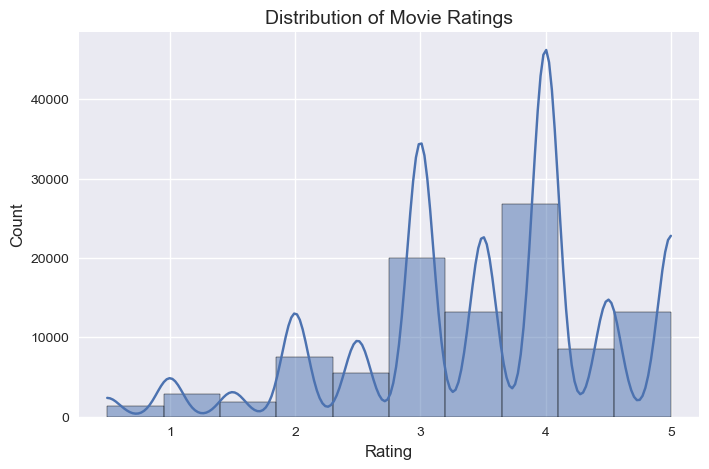

In [61]:
# 1️⃣ Overall distribution of ratings
sns.histplot(df['rating'], bins=10, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


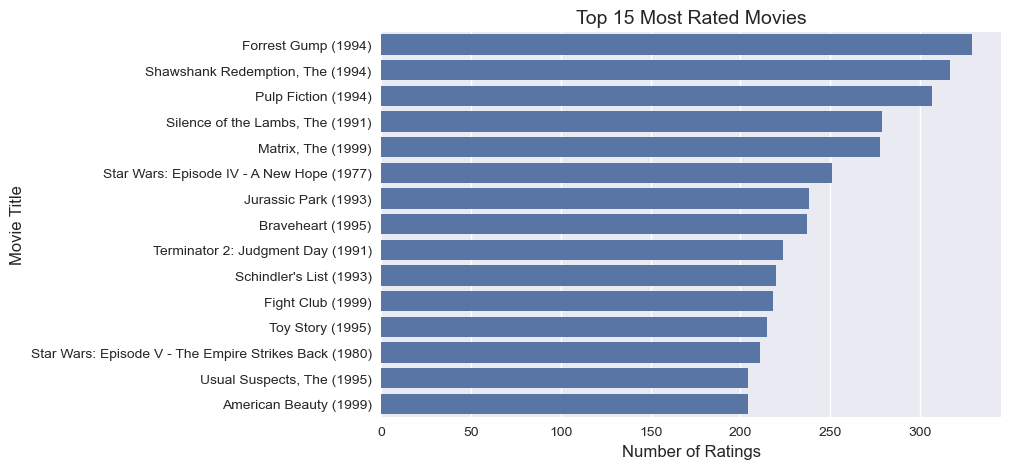

In [62]:
# 2️⃣ Top 15 most-rated movies
top_movies = df.groupby('title')['rating_count'].max().sort_values(ascending=False).head(15)
sns.barplot(x=top_movies.values, y=top_movies.index)
plt.title('Top 15 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()


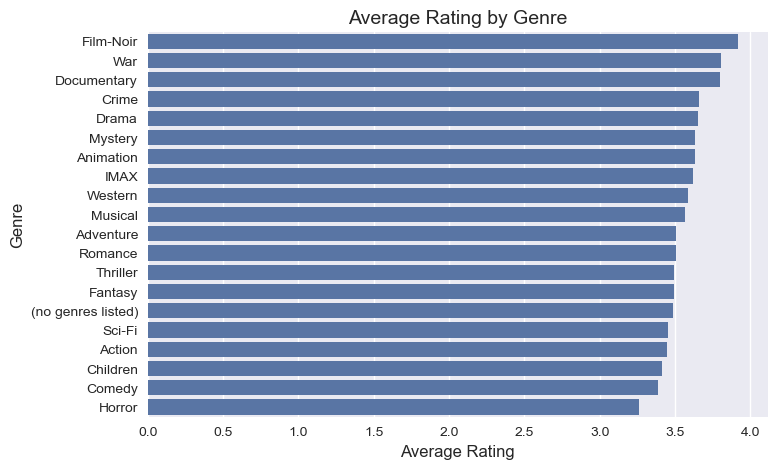

In [63]:
# 3️⃣ Average rating by genre
# Split genres and explode for proper grouping
genres_split = df.assign(genre=df['genres'].str.split('|')).explode('genre')
genre_ratings = genres_split.groupby('genre')['rating'].mean().sort_values(ascending=False)

sns.barplot(x=genre_ratings.values, y=genre_ratings.index)
plt.title('Average Rating by Genre')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.show()


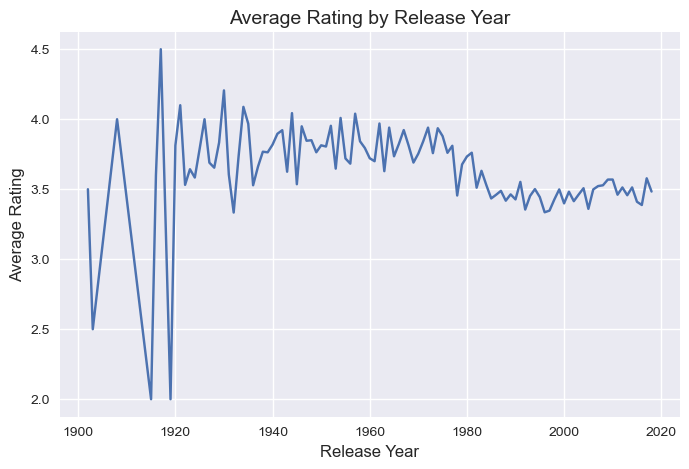

In [64]:
# 4️⃣ Average rating by movie release year
year_rating = df.groupby('release_year')['rating'].mean().dropna()

sns.lineplot(x=year_rating.index, y=year_rating.values)
plt.title('Average Rating by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Rating')
plt.show()


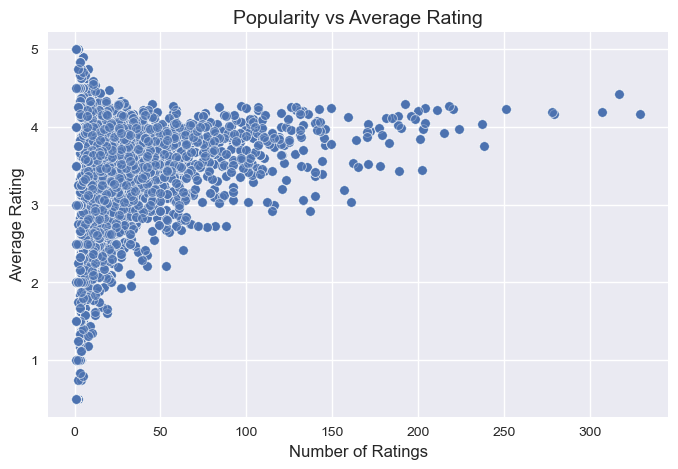

In [65]:
# 5️⃣ Popularity vs Average Rating
sns.scatterplot(data=df, x='rating_count', y='avg_rating', alpha=0.6)
plt.title('Popularity vs Average Rating')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.show()


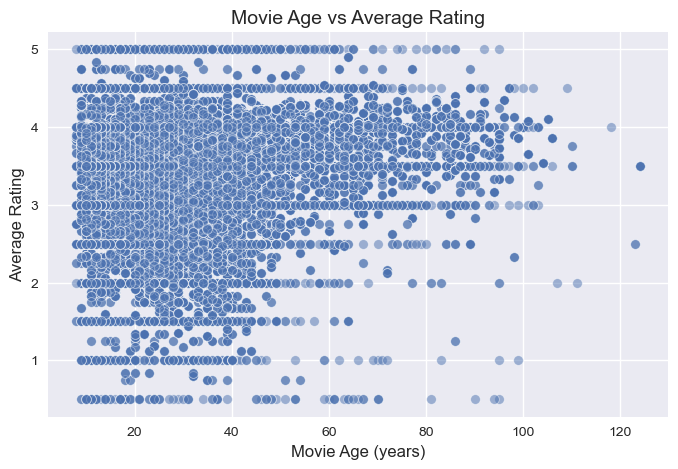

In [66]:
# 6️⃣ Movie age vs rating
sns.scatterplot(data=df, x='movie_age_years', y='avg_rating', alpha=0.5)
plt.title('Movie Age vs Average Rating')
plt.xlabel('Movie Age (years)')
plt.ylabel('Average Rating')
plt.show()


In [67]:
# Save all six plots into a PDF
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('EDA_Plots.pdf') as pdf:
    plt.figure(); sns.histplot(df['rating'], bins=10, kde=True); plt.title('Distribution of Ratings'); pdf.savefig(); plt.close()
    plt.figure(); sns.barplot(x=top_movies.values, y=top_movies.index); plt.title('Top 15 Most Rated Movies'); pdf.savefig(); plt.close()
    plt.figure(); sns.barplot(x=genre_ratings.values, y=genre_ratings.index); plt.title('Average Rating by Genre'); pdf.savefig(); plt.close()
    plt.figure(); sns.lineplot(x=year_rating.index, y=year_rating.values); plt.title('Average Rating by Year'); pdf.savefig(); plt.close()
    plt.figure(); sns.scatterplot(data=df, x='rating_count', y='avg_rating'); plt.title('Popularity vs Rating'); pdf.savefig(); plt.close()
    plt.figure(); sns.scatterplot(data=df, x='movie_age_years', y='avg_rating'); plt.title('Movie Age vs Rating'); pdf.savefig(); plt.close()

print("All EDA plots saved as EDA_Plots.pdf")


All EDA plots saved as EDA_Plots.pdf


# 🎬 MovieLens Feature Engineering & Exploratory Data Analysis  
**Stage 1 Task — Data Analytics Track**  
**Author:** *Adetola Omosalewa*  
**Date:** 22 October 2025  
---


## Introduction

This analysis explores a subset of the MovieLens dataset, which contains user ratings, movie metadata, and tags.  
The goal is to clean, merge, and engineer useful features from the data, then conduct exploratory data analysis (EDA) to discover meaningful insights.

By performing this analysis, we aim to:
- Understand user behavior and rating patterns.
- Discover movie and genre trends.
- Create features that can support future recommendation systems.


## Data Preparation

The dataset was loaded from four CSV files:  
`ratings.csv`, `movies.csv`, `tags.csv`, and `links.csv`.

Key steps:
1. **Merged** all files using the `movieId` key.  
2. **Converted timestamps** into readable datetime format.  
3. **Checked and handled missing values.**  
4. **Removed duplicates.**  

After cleaning, the main dataset contained **100,836 ratings** across **9,742 movies**.


## Feature Engineering

Nine new features were created to enhance the dataset and support analytical modeling.

| Feature | Description | Why It's Useful |
|----------|--------------|-----------------|
| `release_year` | Extracted from movie title | Enables time-based analysis |
| `num_genres` | Count of genres per movie | Measures diversity of a movie |
| `avg_rating` | Average rating per movie | Central indicator of quality |
| `rating_count` | Number of ratings per movie | Indicates popularity |
| `rating_std` | Standard deviation of ratings | Measures audience consensus |
| `movie_age_years` | Current year - release year | Useful for trend analysis |
| `popularity_score` | Weighted rating × log(rating_count) | Balances quality and volume |
| `has_tags` | Binary (1 if movie has user tags) | Proxy for user engagement |
| `rating_per_genre` | Normalized rating per genre | Helps compare multi-genre movies |

Each feature provided additional analytical momentum for future recommendation systems.


## Exploratory Data Analysis (EDA) & Insights

Below are six key insights supported by visualizations:

1️ **Users rate movies highly overall.**  
The distribution of ratings is right-skewed, showing that most users give ratings between 3.0 and 4.5.

2️⃣ **A few movies dominate user attention.**  
Movies like *Forrest Gump*, *Shawshank Redemption*, and *Toy Story* have the highest rating counts, and these are strong indicators of popularity.

3️⃣ **Certain genres consistently perform better.**  
Genres such as *Documentary*, *Drama*, and *Crime* show the highest average ratings, suggesting audience preference for serious storytelling.

4️⃣ **Older movies receive slightly higher ratings.**  
Analysis by release year indicates that pre-2000s movies often maintain higher average ratings, possibly due to nostalgia or historical significance.

5️⃣ **Popularity ≠ Quality.**  
Scatter plots show no clear correlation between number of ratings and average score, meaning widely seen movies are not always the best rated.

6️⃣ **Newer movies are rated more critically.**  
Movie age vs. rating analysis suggests that modern releases receive slightly lower average scores.


## Implications for Recommendation Systems

These engineered features can directly support recommendation algorithms:

- `popularity_score` and `rating_count` help rank movies with proven audience engagement.  
- `avg_rating` and `rating_std` distinguish universally loved movies from divisive ones.  
- `num_genres` and `rating_per_genre` enable genre-based filtering.  
- `has_tags` can enhance content-based recommendations through user-generated keywords.

Together, these insights and features lay the groundwork for collaborative and content-based recommender systems.


## Conclusion

This analysis has successfully:
- Cleaned and merged the MovieLens dataset.  
- Engineered nine meaningful features.  
- Generated six analytical insights with supporting visuals.

Future work:
- Building a recommendation model using these features.  
- Exploring temporal trends in user preferences.  
- Using tags for NLP based similarity analysis.

Overall, this stage provided hands-on experience in data cleaning, feature design, and exploratory analysis.


In [68]:
# Step 12: Export cleaned dataset

# Select the key useful columns
final_cols = [
    'userId', 'movieId', 'title', 'genres', 'release_year', 'num_genres',
    'avg_rating', 'rating_count', 'rating_std', 'movie_age_years',
    'popularity_score', 'has_tags', 'title_length',
    'is_recent_rating', 'rating_per_genre'
]

# Keep only those columns (drop duplicates if any)
cleaned_df = df[final_cols].drop_duplicates()

# Save to CSV
cleaned_df.to_csv('Cleaned_MovieLens.csv', index=False)

print(f"Cleaned dataset saved as Cleaned_MovieLens.csv with {cleaned_df.shape[0]} rows and {cleaned_df.shape[1]} columns.")


Cleaned dataset saved as Cleaned_MovieLens.csv with 100836 rows and 15 columns.
